# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 24     |  |
| :-------------|:-------------|
| Tijl Gerritsen | 6579132 |
| Luuk van Dijk | 6518702 |
| Alexander Boerefijn | 6468624 |
| Planning Groep: 24     |Tijdstip / Tijdspanne  |
|---|---|
| Condensator af (dus sanity checks 1,2,3 af) | 12:45 |
| Sensor af | 17:30 |



## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="image.jpeg" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def Capaciteit_p(A_in,A_out,R_shunt,f):
    C = A_out/(2*np.pi*f*R_shunt*A_in)
    return C *1e12

def Capaciteit(A_in,A_out,R_shunt,f):
    C = A_out/(2*np.pi*f*R_shunt*A_in)
    return C 
def vlakkeplaat(epsilon,A,d):
    C = epsilon*A/d
    return C
epsilon0 = 8.854*10**-12
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [Capaciteit_p(8,0.5,1000,100000)]
C_gemaakt = vlakkeplaat(2.5*epsilon0,0.01,0.004)
C_gemeten = Capaciteit_p(8,0.27,1000,100000)
print(f"Berekende capaciteit plaatcondensator groep 24 is {C[0]:.1f} pF")
print(f"Berekende capaciteit van zelfgemaakte plaatcondensator groep 24 is {C_gemaakt*10**12:f} pF")
print(C_gemeten)
A_out = C_gemaakt*2*np.pi*100000*1000*8
print(A_out)

Berekende capaciteit plaatcondensator groep 24 is 99.5 pF
Berekende capaciteit van zelfgemaakte plaatcondensator groep 24 is 55.337500 pF
53.71479329351468
0.27815661354884025


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![meting](meting.jpeg)
![condensator](processed-304DAECD-972A-45DC-8600-CDA194471B46.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 24| 55.3 pF | 0.28 V | 0.27 V | 53.7 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_6540.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die gewicht meet. Door d te laten veranderen en te meten.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_6545.jpeg)

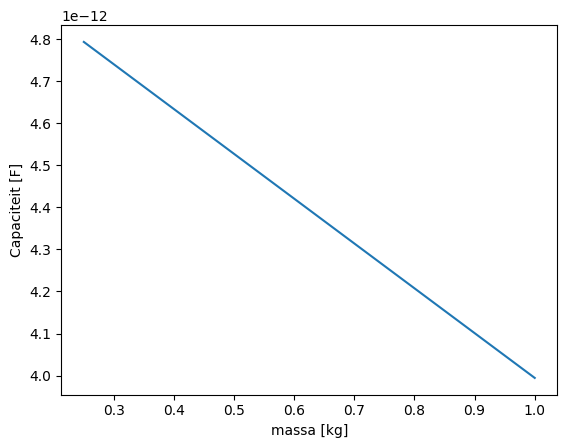

De geschatte waarde voor de veerconstante is -687.1


In [12]:

g = 9.81
C_schat_vooraf = 100 # gok voor de veerconstante 
A = 0.029
d_begin = 0.05 
def cap_schat(M,k):
    return epsilon0*A/(d_begin-(M*g/k))
capac_schat = np.array([2,5])*1e-12
massa_schat = np.array([0.25,1])

val1, cov1 = curve_fit(cap_schat,massa_schat,capac_schat)
C_geschat = val1[0]

plt.figure()
plt.plot(massa_schat,cap_schat(massa_schat,*val1))
plt.xlabel('massa [kg]')
plt.ylabel('Capaciteit [F]')
plt.show()
print('De geschatte waarde voor de veerconstante is %.1f' % C_geschat)

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 80 | 400 |
| gemiddelde capaciteit| 160 | 1040 |
| maximale capaciteit| 250 | 1240 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](tudelftLogo.png)
![meting 2](tudelftLogo.png)

## Opdracht 7: Plot de kalibratiegrafiek.

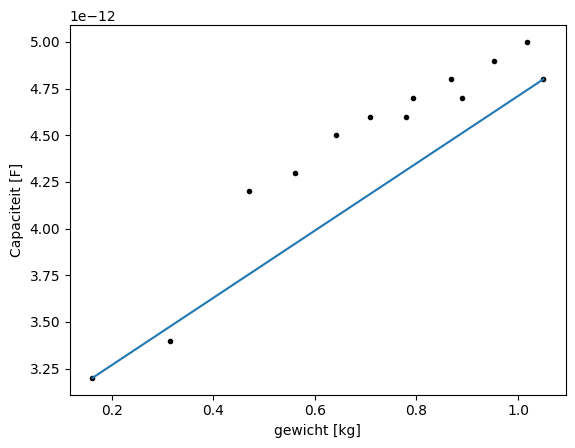

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

C_ref = 34.1 # pF
g = 9.81


def Kracht(u,c):
    return c*u
0.162
gewicht = np.array([0.162, 0.314, 0.471, 0.561, 0.641,0.708, 0.793, 0.869, 0.952, 1.018,0.780,0.890,1.050])
kracht = gewicht*g
Condensator_waarde = np.array([3.2, 3.4, 4.2, 4.3, 4.5,4.6, 4.7, 4.8, 4.9, 5.0,4.6,4.7,4.8])*10**-12

A = 0.029
d = epsilon0*A/Condensator_waarde
u = 0.28-d
gewicht_schat = np.array([0.162,1.050])
condensator_schat = np.array([3.2,4.8])*10**-12

val,cov = curve_fit(Kracht,u,kracht)
C = val[0]
u_c = np.sqrt(cov[0,0])

plt.figure()
plt.plot(gewicht,Condensator_waarde,'k.')
plt.plot(gewicht_schat,condensator_schat)
plt.plot()
plt.xlabel('gewicht [kg]')
plt.ylabel('Capaciteit [F]')
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Groter oppervlakte voor condensator.
* Betere spons/beter medium
* 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

Onze data en meetopstelling was niet nauwkeurig genoeg, en komt niet overeen met onze schatting. De veerconstante van de spons is niet constant, en ons oppervlak was niet groot genoeg om een goeie variatie in capaciteit te krijgen waardoor de onzekerheid in onze metingen heel groot werd.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.